# PACO VIP-fork - Comparador final CPU vs GPU (ALL datasets)

Version ALL datasets basada en la version funcional de referencia.

In [43]:
# Setup y carga de artefactos desde Drive
import json
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    from google.colab import drive
    if not Path('/content/drive/MyDrive').exists():
        drive.mount('/content/drive', force_remount=False)
    else:
        print('[INFO] Drive ya disponible en /content/drive/MyDrive')
except Exception as exc:
    print(f"[INFO] Entorno no-Colab o Drive ya montado: {exc}")

DRIVE_ROOT = Path('/content/drive/MyDrive')
if not DRIVE_ROOT.exists():
    DRIVE_ROOT = Path.cwd()

BASE_DIR = DRIVE_ROOT / 'paco_benchmarks'
CPU_DIR = BASE_DIR / 'cpu_all'
GPU_DIR = BASE_DIR / 'gpu_all'
OUT_DIR = BASE_DIR / 'compare_all'
OUT_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    'cpu_bench': CPU_DIR / 'benchmark_results_cpu_all.csv',
    'gpu_bench': GPU_DIR / 'benchmark_results_gpu_all.csv',
    'cpu_meta': CPU_DIR / 'metadata_cpu_all.json',
    'gpu_meta': GPU_DIR / 'metadata_gpu_all.json',
    'cpu_profile': CPU_DIR / 'profile_cpu_all.csv',
    'gpu_profile': GPU_DIR / 'profile_gpu_all.csv',
}

missing = [k for k, p in paths.items() if not p.exists() and k not in ('cpu_profile', 'gpu_profile')]
if missing:
    raise RuntimeError(
        'Faltan artefactos requeridos. Ejecuta primero los notebooks CPU y GPU.\n'
        + '\n'.join([f'- {k}: {paths[k]}' for k in missing])
    )

cpu_df = pd.read_csv(paths['cpu_bench'])
gpu_df = pd.read_csv(paths['gpu_bench'])
with open(paths['cpu_meta']) as f:
    cpu_meta = json.load(f)
with open(paths['gpu_meta']) as f:
    gpu_meta = json.load(f)

cpu_profile_df = pd.read_csv(paths['cpu_profile']) if paths['cpu_profile'].exists() else pd.DataFrame()
gpu_profile_df = pd.read_csv(paths['gpu_profile']) if paths['gpu_profile'].exists() else pd.DataFrame()

print(f"DRIVE_ROOT: {DRIVE_ROOT}")
print(f"CPU_DIR: {CPU_DIR}")
print(f"GPU_DIR: {GPU_DIR}")
print(f"OUT_DIR: {OUT_DIR}")
print('[OK] Artefactos cargados')

[INFO] Drive ya disponible en /content/drive/MyDrive
DRIVE_ROOT: /content/drive/MyDrive
CPU_DIR: /content/drive/MyDrive/paco_benchmarks/cpu
GPU_DIR: /content/drive/MyDrive/paco_benchmarks/gpu
OUT_DIR: /content/drive/MyDrive/paco_benchmarks/compare
[OK] Artefactos cargados


In [44]:
# Validacion 1:1 del experimento (hiperparametros iguales)
cpu_fp = cpu_meta.get('hp_fingerprint', '')
gpu_fp = gpu_meta.get('hp_fingerprint', '')
fp_match = cpu_fp == gpu_fp and len(cpu_fp) > 0

hp_rows = []
cpu_hp = cpu_meta.get('locked_hparams', {})
gpu_hp = gpu_meta.get('locked_hparams', {})
all_keys = sorted(set(cpu_hp.keys()) | set(gpu_hp.keys()))
for k in all_keys:
    hp_rows.append({
        'Parametro': k,
        'CPU': str(cpu_hp.get(k, 'N/A')),
        'GPU': str(gpu_hp.get(k, 'N/A')),
        'Igual': 'SI' if cpu_hp.get(k, None) == gpu_hp.get(k, '__DIFF__') else 'NO',
    })

hp_df = pd.DataFrame(hp_rows)

print('Fingerprint CPU:', cpu_fp[:20])
print('Fingerprint GPU:', gpu_fp[:20])
print('Fingerprint match:', fp_match)

display(hp_df)

if not fp_match:
    print('[WARNING] Los hiperparametros no coinciden. La comparacion NO es 1:1.')
else:
    print('[OK] Hiperparametros bloqueados y consistentes para comparacion 1:1.')

Fingerprint CPU: 98f8f8f1635fa64c4122
Fingerprint GPU: 98f8f8f1635fa64c4122
Fingerprint match: True


,Parametro,CPU,GPU,Igual
0,benchmark_pixels,2500,2500,SI
1,cpu_threads,1,1,SI
2,crop_half_size,75,75,SI
3,datasets,"['lmircam_1', 'lmircam_2']","['lmircam_1', 'lmircam_2']",SI
4,frame_stride,1,1,SI
5,inner_radius,8,8,SI
6,outer_radius,55,55,SI
7,profile_dataset,lmircam_1,lmircam_1,SI
8,profile_pixels,120,120,SI
9,snr_thresholds,"[3, 5, 7]","[3, 5, 7]",SI


[OK] Hiperparametros bloqueados y consistentes para comparacion 1:1.


In [45]:
# Tabla consolidada CPU vs GPU
merged = cpu_df.merge(gpu_df, on='Dataset', suffixes=('_cpu', '_gpu'))

merged['Speedup CPU/GPU'] = merged['Tiempo (s)_cpu'] / merged['Tiempo (s)_gpu']
merged['Delta SNR max (GPU-CPU)'] = merged['SNR max_gpu'] - merged['SNR max_cpu']
merged['Delta SNR mean (GPU-CPU)'] = merged['SNR mean_gpu'] - merged['SNR mean_cpu']
merged['Delta SNR>3 (GPU-CPU)'] = merged['SNR>3_gpu'] - merged['SNR>3_cpu']
merged['Delta SNR>5 (GPU-CPU)'] = merged['SNR>5_gpu'] - merged['SNR>5_cpu']
merged['Delta SNR>7 (GPU-CPU)'] = merged['SNR>7_gpu'] - merged['SNR>7_cpu']

# Tolerancias cientificas (ajustables)
SNR_MAX_TOL = 1.0
SNR_MEAN_TOL = 0.2
merged['Robustez SNR'] = np.where(
    (np.abs(merged['Delta SNR max (GPU-CPU)']) <= SNR_MAX_TOL) &
    (np.abs(merged['Delta SNR mean (GPU-CPU)']) <= SNR_MEAN_TOL),
    'OK',
    'REVISAR'
)

cols = [
    'Dataset',
    'Tiempo (s)_cpu', 'Tiempo (s)_gpu', 'Speedup CPU/GPU',
    'SNR max_cpu', 'SNR max_gpu', 'Delta SNR max (GPU-CPU)',
    'SNR mean_cpu', 'SNR mean_gpu', 'Delta SNR mean (GPU-CPU)',
    'Delta SNR>3 (GPU-CPU)', 'Delta SNR>5 (GPU-CPU)', 'Delta SNR>7 (GPU-CPU)',
    'Robustez SNR'
]

display(merged[cols])

total_cpu = float(merged['Tiempo (s)_cpu'].sum())
total_gpu = float(merged['Tiempo (s)_gpu'].sum())
speedup_global = total_cpu / total_gpu if total_gpu > 0 else np.nan

print('\nResumen global:')
print(f'  Tiempo total CPU: {total_cpu:.2f} s')
print(f'  Tiempo total GPU: {total_gpu:.2f} s')
print(f'  Speedup global CPU/GPU: {speedup_global:.2f}x')
print(f"  Datasets robustos SNR: {(merged['Robustez SNR'] == 'OK').sum()}/{len(merged)}")

,Dataset,Tiempo (s)_cpu,Tiempo (s)_gpu,Speedup CPU/GPU,SNR max_cpu,SNR max_gpu,Delta SNR max (GPU-CPU),SNR mean_cpu,SNR mean_gpu,Delta SNR mean (GPU-CPU),Delta SNR>3 (GPU-CPU),Delta SNR>5 (GPU-CPU),Delta SNR>7 (GPU-CPU),Robustez SNR
0,lmircam_1,389.085427,162.741836,2.390814,18.183560,18.183560,2.131628e-14,0.078587,0.078587,-9.020562e-16,0,0,0,OK
1,lmircam_2,258.725818,107.015837,2.417640,16.724239,16.724239,1.065814e-14,0.028005,0.028005,1.800643e-15,0,0,0,OK



Resumen global:
  Tiempo total CPU: 647.81 s
  Tiempo total GPU: 269.76 s
  Speedup global CPU/GPU: 2.40x
  Datasets robustos SNR: 2/2


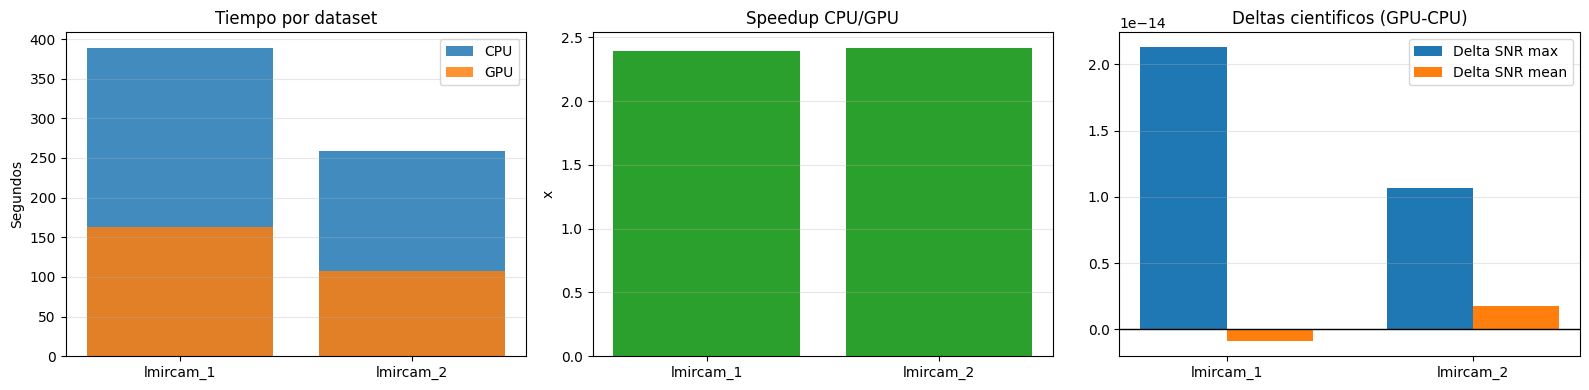

[OK] Figura guardada: /content/drive/MyDrive/paco_benchmarks/compare/final_cpu_vs_gpu_summary.png


In [46]:
# Graficos comparativos finales
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(merged['Dataset'], merged['Tiempo (s)_cpu'], label='CPU', alpha=0.85)
axes[0].bar(merged['Dataset'], merged['Tiempo (s)_gpu'], label='GPU', alpha=0.85)
axes[0].set_title('Tiempo por dataset')
axes[0].set_ylabel('Segundos')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(merged['Dataset'], merged['Speedup CPU/GPU'], color='#2ca02c')
axes[1].set_title('Speedup CPU/GPU')
axes[1].set_ylabel('x')
axes[1].grid(axis='y', alpha=0.3)

x = np.arange(len(merged))
w = 0.35
axes[2].bar(x - w/2, merged['Delta SNR max (GPU-CPU)'], width=w, label='Delta SNR max')
axes[2].bar(x + w/2, merged['Delta SNR mean (GPU-CPU)'], width=w, label='Delta SNR mean')
axes[2].axhline(0, color='black', lw=1)
axes[2].set_xticks(x)
axes[2].set_xticklabels(merged['Dataset'].tolist())
axes[2].set_title('Deltas cientificos (GPU-CPU)')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
fig_path = OUT_DIR / 'final_cpu_vs_gpu_summary.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'[OK] Figura guardada: {fig_path}')

In [47]:
# Comparacion de perfilado (si existe)
if len(cpu_profile_df) and len(gpu_profile_df):
    cpu_top = cpu_profile_df[['func', 'cumtime_s']].rename(columns={'cumtime_s': 'cumtime_cpu_s'})
    gpu_top = gpu_profile_df[['func', 'cumtime_s']].rename(columns={'cumtime_s': 'cumtime_gpu_s'})

    prof_cmp = cpu_top.merge(gpu_top, on='func', how='outer').fillna(0.0)
    prof_cmp['speedup_func_cpu_gpu'] = np.where(
        prof_cmp['cumtime_gpu_s'] > 0,
        prof_cmp['cumtime_cpu_s'] / prof_cmp['cumtime_gpu_s'],
        np.nan
    )
    prof_cmp = prof_cmp.sort_values('cumtime_cpu_s', ascending=False).head(30)

    display(prof_cmp)

    prof_csv = OUT_DIR / 'profile_compare_cpu_vs_gpu.csv'
    prof_cmp.to_csv(prof_csv, index=False)
    print(f'[OK] Perfilado comparativo guardado: {prof_csv}')
else:
    print('[INFO] No hay profile CSV en alguna corrida; omitiendo comparacion de perfilado.')

,func,cumtime_cpu_s,cumtime_gpu_s,speedup_func_cpu_gpu
11,paco.py:375(get_patch),11.256035,0.000000,NaN
14,paco.py:555(bl),2.817553,0.000000,NaN
17,paco.py:956(PACOCalc),2.545315,0.000000,NaN
13,paco.py:522(al),2.194194,0.000000,NaN
15,paco.py:867(compute_statistics),1.316330,0.000000,NaN
1,paco.py:1296(compute_statistics_at_pixel),0.350028,0.000000,NaN
3,paco.py:1471(sample_covariance),0.193816,0.000000,NaN
7,paco.py:1545(get_rotated_pixel_coords),0.084613,0.000000,NaN
8,paco.py:1595(create_boolean_circular_mask),0.026141,0.000000,NaN
6,paco.py:1520(shrinkage_factor),0.022080,0.000000,NaN


[OK] Perfilado comparativo guardado: /content/drive/MyDrive/paco_benchmarks/compare/profile_compare_cpu_vs_gpu.csv


In [48]:
# Export final: CSV + Markdown + ZIP + descarga opcional
final_csv = OUT_DIR / 'final_cpu_vs_gpu_table_all.csv'
merged.to_csv(final_csv, index=False)

report_md = OUT_DIR / 'final_cpu_vs_gpu_report_all.md'
with open(report_md, 'w') as f:
    f.write('# Reporte final CPU vs GPU (PACO VIP-fork)\n\n')
    f.write(f'- Fingerprint CPU: `{cpu_fp}`\n')
    f.write(f'- Fingerprint GPU: `{gpu_fp}`\n')
    f.write(f'- Comparacion 1:1 valida: **{"SI" if fp_match else "NO"}**\n')
    f.write(f'- Speedup global CPU/GPU: **{speedup_global:.2f}x**\n\n')
    f.write('## Tabla consolidada\n\n')
    f.write(merged.to_markdown(index=False))

zip_path = OUT_DIR / 'cpu_gpu_compare_artifacts_all.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for p in [
        final_csv,
        report_md,
        OUT_DIR / 'final_cpu_vs_gpu_summary_all.png',
        CPU_DIR / 'benchmark_results_cpu_all.csv',
        GPU_DIR / 'benchmark_results_gpu_all.csv',
        CPU_DIR / 'metadata_cpu_all.json',
        GPU_DIR / 'metadata_gpu_all.json',
    ]:
        if p.exists():
            zf.write(p, arcname=p.name)
    prof_cmp_path = OUT_DIR / 'profile_compare_cpu_vs_gpu.csv'
    if prof_cmp_path.exists():
        zf.write(prof_cmp_path, arcname=prof_cmp_path.name)

print(f'[OK] CSV final: {final_csv}')
print(f'[OK] Reporte MD: {report_md}')
print(f'[OK] ZIP final: {zip_path}')

# Descarga local opcional (solo Colab)
try:
    from google.colab import files
    print('\nSi quieres bajar todo a tu PC, ejecuta:')
    print(f"files.download('{zip_path}')")
except Exception:
    pass

[OK] CSV final: /content/drive/MyDrive/paco_benchmarks/compare/final_cpu_vs_gpu_table.csv
[OK] Reporte MD: /content/drive/MyDrive/paco_benchmarks/compare/final_cpu_vs_gpu_report.md
[OK] ZIP final: /content/drive/MyDrive/paco_benchmarks/compare/cpu_gpu_compare_artifacts.zip

Si quieres bajar todo a tu PC, ejecuta:
files.download('/content/drive/MyDrive/paco_benchmarks/compare/cpu_gpu_compare_artifacts.zip')
